In [1]:
import os
import operator
from typing import Annotated, Literal
from pydantic import BaseModel
from tavily import TavilyClient
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
loader = PyPDFLoader("../documents/evs_oil_price_shock.pdf")
raw_docs = loader.load()

print(f"Loaded {len(raw_docs)} pages")

Loaded 15 pages


In [3]:
splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150)
chunks = splitter.split_documents(raw_docs)

print(f"Split into {len(chunks)} chunks")

Split into 51 chunks


In [4]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

In [5]:
# in-memory only; re-running this cell re-embeds from scratch
vectorstore = Chroma(
    collection_name="agentic_rag",
    embedding_function=embeddings,
)

vectorstore.add_documents(documents=chunks)

print("Vector store ready")

Vector store ready


In [6]:
llm = ChatOpenAI(model="gpt-5-mini")        # route_question and generate

agent_llm = ChatOpenAI(model="gpt-5-mini")  # agent node; tools bound later

In [7]:
class AgenticRAGState(MessagesState):

    query: str
    retrieved_docs: Annotated[list[Document], operator.add]
    context: Annotated[str, operator.add]
    generation: str
    needs_retrieval: bool
    retrieval_count: int       # incremented after each tool-call round
    max_retrieval_steps: int   # cap on tool-call rounds before forcing generate

In [8]:
class RouteDecision(BaseModel):

    needs_retrieval: bool

In [9]:
@tool(response_format="content_and_artifact")
def vector_store_search(query: str, k: int = 3):
    """Search the vector store for relevant document passages.
    Adjust k (default 3) to retrieve more or fewer passages."""
    
    docs = vectorstore.similarity_search(query, k=k)
    context = "\n\n## Vector Store Results\n\n" + "\n\n".join(d.page_content for d in docs)
    
    return context, docs

In [10]:
@tool(response_format="content_and_artifact")
def web_search(query: str, max_results: int = 3):
    """Search the web for current or real-time information.
    Adjust max_results (default 3) to control how many results are returned."""
    
    client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])
    response = client.search(query, max_results=max_results)
    
    docs = [
        Document(
            page_content=r["content"],
            metadata={"source": r["url"], "title": r.get("title", "")},
        )
        for r in response["results"]
    ]
    content = "\n\n## Web Search Results\n\n" + "\n\n".join(d.page_content for d in docs)
    return content, docs

In [11]:
tools = [vector_store_search, web_search]

agent_llm_with_tools = agent_llm.bind_tools(tools)

tool_node = ToolNode(tools)

In [12]:
# route_question node — classifies whether the query needs retrieval
def route_question(state: AgenticRAGState) -> dict:

    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "Classify whether the following question requires retrieving information from a specialized document or the web, or can be answered from your own general knowledge."),
        ("human", "{query}"),
    ])

    chain = prompt_template | llm.with_structured_output(RouteDecision)
    decision = chain.invoke({"query": state["query"]})

    return {"needs_retrieval": decision.needs_retrieval}

In [13]:
AGENT_SYSTEM_PROMPT = (
    "You are a retrieval agent with access to two tools:\n\n"
    "1. vector_store_search — use this for questions that can be answered from the internal document: "
    "a technical report titled 'Will EVs Dampen the Oil Price Shock?' covering EV adoption trajectories, "
    "oil demand displacement scenarios, fleet turnover dynamics, battery cost trends, OPEC+ supply behavior, "
    "and energy price volatility projections through 2050. "
    "Use this tool whenever the query references the report, its findings, its projections, or any topic "
    "that would plausibly appear in a domain-specific EV/oil-market research document. "
    "You may increase k beyond the default if broader coverage of the document is needed.\n\n"
    "2. web_search — use this for current or real-time information not covered by the document, such as "
    "recent market data, news, or statistics from 2024 onward. "
    "Always rephrase the query into a concise, keyword-optimized web search string before calling this tool.\n\n"
    "You may call one tool, both tools, or no tool depending on what the query requires. "
    "When both document knowledge and current data are relevant, call both tools."
)

# agent node — decides which tool(s) to call based on the query
def agent(state: AgenticRAGState) -> dict:

    messages = state["messages"]
    if not messages:
        messages = [SystemMessage(content=AGENT_SYSTEM_PROMPT),
                    HumanMessage(content=state["query"])]

    response = agent_llm_with_tools.invoke(messages)

    return {"messages": [response]}

In [14]:
# collect_tool_output node — drains ToolMessages into state fields
def collect_tool_output(state: AgenticRAGState) -> dict:

    tool_messages = [m for m in state["messages"] if isinstance(m, ToolMessage)]
    all_docs, context_parts = [], []

    for msg in tool_messages:
        context_parts.append(msg.content)
        all_docs.extend(msg.artifact)

    return {
        "context": "\n\n".join(context_parts),
        "retrieved_docs": all_docs,
    }

In [15]:
# generate node — produces the final answer with or without retrieved context
def generate(state: AgenticRAGState) -> dict:

    query = state["query"]
    context = state.get("context") or ""

    if context:
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the question using only the context below.\n\nContext:\n{context}"),
            ("human", "{query}"),
        ])
        response = (prompt_template | llm).invoke({"context": context, "query": query})

    else:
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the following question from your general knowledge."),
            ("human", "{query}"),
        ])
        response = (prompt_template | llm).invoke({"query": query})

    return {"generation": response.content}

In [17]:
# check_retrieval_limit node — increments the retrieval counter after each tool round
def check_retrieval_limit(state: AgenticRAGState) -> dict:
    count = state.get("retrieval_count", 0)
    
    return {"retrieval_count": count + 1}

In [18]:
def route_after_classification(state: AgenticRAGState) -> Literal["agent", "generate"]:
    return "agent" if state["needs_retrieval"] else "generate"

def route_after_agent(state: AgenticRAGState) -> Literal["tools", "collect_tool_output"]:
    return "tools" if state["messages"][-1].tool_calls else "collect_tool_output"

def route_after_limit_check(state: AgenticRAGState) -> Literal["agent", "collect_tool_output"]:
    return "collect_tool_output" if state["retrieval_count"] >= state["max_retrieval_steps"] else "agent"

In [19]:
graph_builder = StateGraph(AgenticRAGState)

graph_builder.add_node("route_question", route_question)
graph_builder.add_node("agent", agent)
graph_builder.add_node("tools", tool_node)
graph_builder.add_node("check_retrieval_limit", check_retrieval_limit)
graph_builder.add_node("collect_tool_output", collect_tool_output)
graph_builder.add_node("generate", generate)

graph_builder.add_edge(START, "route_question")
graph_builder.add_conditional_edges("route_question", route_after_classification)
graph_builder.add_conditional_edges("agent", route_after_agent)
graph_builder.add_edge("tools", "check_retrieval_limit")
graph_builder.add_conditional_edges("check_retrieval_limit", route_after_limit_check)
graph_builder.add_edge("collect_tool_output", "generate")
graph_builder.add_edge("generate", END)

In [20]:
graph = graph_builder.compile()

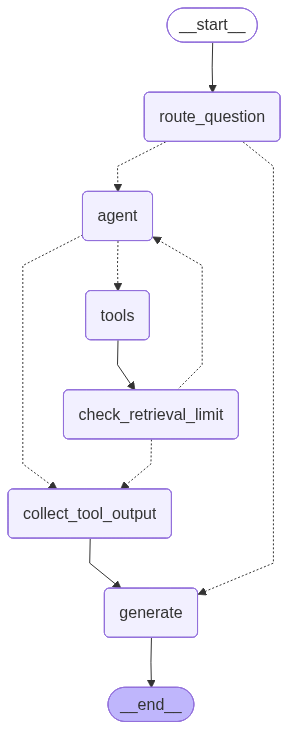

In [21]:
graph

In [22]:
# Case 1: vector store only — domain-specific question about the PDF
query_vs = "According to the report, how will the adoption of electric vehicles impact oil demand?"

result_vs = graph.invoke({"query": query_vs, "messages": [], "retrieved_docs": [], "context": "", "retrieval_count": 0, "max_retrieval_steps": 5})

In [23]:
print("=== CASE 1: Vector Store Only ===")
print(f"needs_retrieval  : {result_vs['needs_retrieval']}")
print(f"retrieval_count  : {result_vs['retrieval_count']}")
print(f"retrieved_docs   : {len(result_vs.get('retrieved_docs') or [])} docs")
print(f"context preview  : {result_vs.get('context', '')[:120]}...")
print(f"\nGeneration:\n{result_vs['generation']}")

=== CASE 1: Vector Store Only ===
needs_retrieval  : True
retrieval_count  : 1
retrieved_docs   : 6 docs
context preview  : 

## Vector Store Results

Will EVs Dampen the Oil Price Shock?
Version 1.0
Research Report — For Educational and RAG Pi...

Generation:
Briefly, the report says EV adoption will reduce oil demand but not quickly or uniformly:

- EVs primarily displace gasoline demand from passenger cars; diesel (trucks, buses, equipment) is much harder to electrify.  
- By flattening or reversing road-transport demand growth, EVs raise the chance that global spare capacity stays above the 2–3 million barrels/day buffer, so the marginal (near‑term) effect on price dynamics can be important even if aggregate displacement is modest.  
- Full fleet turnover is slow (global stock ~1.4 billion vehicles; ~90 million new cars/year; typical lifetimes 15–20+ years), so substantial demand reduction is gradual and will be most pronounced after ~2035 and first in advanced economies.  
- There

In [24]:
# Case 2: web search only — current information not in the PDF
query_web = "What is the current temperature in New Delhi?"

result_web = graph.invoke({"query": query_web, "messages": [], "retrieved_docs": [], "context": "", "retrieval_count": 0, "max_retrieval_steps": 5})

In [25]:
print("=== CASE 2: Web Search Only ===")
print(f"needs_retrieval  : {result_web['needs_retrieval']}")
print(f"retrieval_count  : {result_web['retrieval_count']}")
print(f"retrieved_docs   : {len(result_web.get('retrieved_docs') or [])} docs")
print(f"context preview  : {result_web.get('context', '')[:120]}...")
print(f"\nGeneration:\n{result_web['generation']}")

=== CASE 2: Web Search Only ===
needs_retrieval  : True
retrieval_count  : 1
retrieved_docs   : 3 docs
context preview  : 

## Web Search Results

{'location': {'name': 'New Delhi', 'region': 'Delhi', 'country': 'India', 'lat': 28.6, 'lon': 7...

Generation:
The current temperature in New Delhi is 38.0°C (100.4°F).


In [26]:
# Case 3: both tools — requires document context AND current web data
query_both = "Compare what the EV report projects for 2030 oil demand with current oil demand due to Iran-US War."

result_both = graph.invoke({"query": query_both, "messages": [], "retrieved_docs": [], "context": "", "retrieval_count": 0, "max_retrieval_steps": 5})

In [27]:
print("=== CASE 3: Both Tools ===")
print(f"needs_retrieval  : {result_both['needs_retrieval']}")
print(f"retrieval_count  : {result_both['retrieval_count']}")
print(f"retrieved_docs   : {len(result_both.get('retrieved_docs') or [])} docs")
print(f"context preview  : {result_both.get('context', '')[:120]}...")
print(f"\nGeneration:\n{result_both['generation']}")

=== CASE 3: Both Tools ===
needs_retrieval  : True
retrieval_count  : 1
retrieved_docs   : 10 docs
context preview  : 

## Vector Store Results

Will EVs Dampen the Oil Price Shock?
Version 1.0
Research Report — For Educational and RAG Pi...

Generation:
Short answer: the EV report excerpts provided do not give a specific numeric global oil‑demand projection for 2030. They describe a gradual, structural demand reduction from accelerating EV adoption that becomes economically material in the early 2030s and that can flatten or reverse demand growth (especially gasoline), increasing the chance that spare capacity stays above a 2–3 million barrels‑per‑day insurance threshold. By contrast, the Iran–US war effects described in the web snippets are an immediate near‑term shock: the IEA sees a small demand decline of about 80,000 bpd in 2026 and a much larger change versus pre‑war forecasts (the web result cites global demand being almost 1 million bpd less than forecast before the Iran war),

In [30]:
# Case 3b: multi-round retrieval — query designed to trigger iterative tool calls
# The agent is expected to: (1) search the vector store for report projections,
# then (2) search the web for current data, then (3) search again to fill any gaps.
query_multi = (
    "Step 1: Look up what the EV report projects for oil demand displacement by 2030 and 2050. "
    "Step 2: Search for the latest 2024-2025 EV sales data and battery cost trends. "
    "Step 3: Search for any recent analyst forecasts that revise those oil demand projections upward or downward. "
    "Synthesize all three into a coherent answer."
)

result_multi = graph.invoke({"query": query_multi, "messages": [], "retrieved_docs": [], "context": "", "retrieval_count": 0, "max_retrieval_steps": 5})

In [32]:
print("=== CASE 3b: Multi-Round Retrieval ===")
print(f"needs_retrieval  : {result_multi['needs_retrieval']}")
print(f"retrieval_count  : {result_multi['retrieval_count']}")
print(f"retrieved_docs   : {len(result_multi.get('retrieved_docs') or [])} docs")
print(f"context preview  : {result_multi.get('context', '')[:120]}...")
print(f"\nGeneration:\n{result_multi['generation']}")

=== CASE 3b: Multi-Round Retrieval ===
needs_retrieval  : True
retrieval_count  : 2
retrieved_docs   : 10 docs
context preview  : 

## Vector Store Results

Will EVs Dampen the Oil Price Shock?
Version 1.0
Research Report — For Educational and RAG Pi...

Generation:
Short answer up front
- The provided EV report excerpts do not give explicit numeric oil‑displacement projections for 2030 or 2050.  
- External material included in the context (IEA snippets in the web results) gives a mid‑single‑million barrels/day reduction by 2030 (roughly 5–6 mb/d) and larger reductions by the mid‑2030s (cited ~13 mb/d by 2035), but also an IEA framing that total oil demand may only be down ~8% by 2050 versus 2024.  
- The report emphasizes (qualitatively) that EVs will mainly displace gasoline (passenger cars), diesel is harder to electrify, fleet turnover takes decades, and outcomes depend heavily on emerging‑market vehicle growth and OPEC+ production policy.

Step 1 — What the EV report (Will EVs Da

In [28]:
# Case 4: no retrieval — answerable from general knowledge
query_none = "Explain the difference between kinetic energy and potential energy."

result_none = graph.invoke({"query": query_none, "messages": [], "retrieved_docs": [], "context": "", "retrieval_count": 0, "max_retrieval_steps": 5})

In [29]:
print("=== CASE 4: No Retrieval ===")
print(f"needs_retrieval  : {result_none['needs_retrieval']}")
print(f"retrieval_count  : {result_none['retrieval_count']}")
print(f"retrieved_docs   : {len(result_none.get('retrieved_docs') or [])} docs")
print(f"context preview  : {result_none.get('context', '') or '(none)'}")
print(f"\nGeneration:\n{result_none['generation']}")

=== CASE 4: No Retrieval ===
needs_retrieval  : False
retrieval_count  : 0
retrieved_docs   : 0 docs
context preview  : (none)

Generation:
Kinetic energy and potential energy are two basic forms of mechanical energy. The main difference is that kinetic energy is energy of motion, while potential energy is stored energy due to an object's position or configuration.

Key points

- Kinetic energy (KE)
  - Definition: energy an object has because of its motion.
  - Formula (linear): KE = 1/2 · m · v^2, where m is mass and v is speed.
  - Also exists for rotation: KE_rot = 1/2 · I · ω^2 (I = moment of inertia, ω = angular speed).
  - Depends only on mass and speed; always nonnegative.
  - Example: a moving car, a flying baseball, or a spinning wheel.

- Potential energy (PE)
  - Definition: energy stored in an object because of its position in a force field or its configuration.
  - Common forms and formulas:
    - Gravitational near Earth: PE = m · g · h (h = height above chosen reference